# Credit Card Fraud Detection

##  Introduction

This project delivers a production-oriented fraud detection pipeline on the canonical European credit card fraud dataset. With a class imbalance ratio of **578:1** (legitimate vs. fraudulent), standard accuracy metrics are rendered uninformative - this analysis therefore anchors all evaluation on **Precision-Recall AUC (PR-AUC)**, **ROC-AUC**, and the **Gini coefficient**, which are the industry-standard metrics for credit risk and fraud analytics.

**Key analytical objectives:**
- Quantify the discriminatory power of PCA-transformed behavioral features across transaction classes
- Identify fraud-specific temporal and monetary patterns with operational relevance
- Build and compare ensemble classifiers optimized for high-recall fraud identification
- Deliver business-interpretable findings aligned with fraud operations and risk management priorities

**Dataset:** 284,807 transactions over 48 hours (September 2013, European cardholders). Features V1–V28 are PCA-anonymized; `Time` and `Amount` are in original scale. Target: `Class` (1 = fraud, 0 = legitimate)

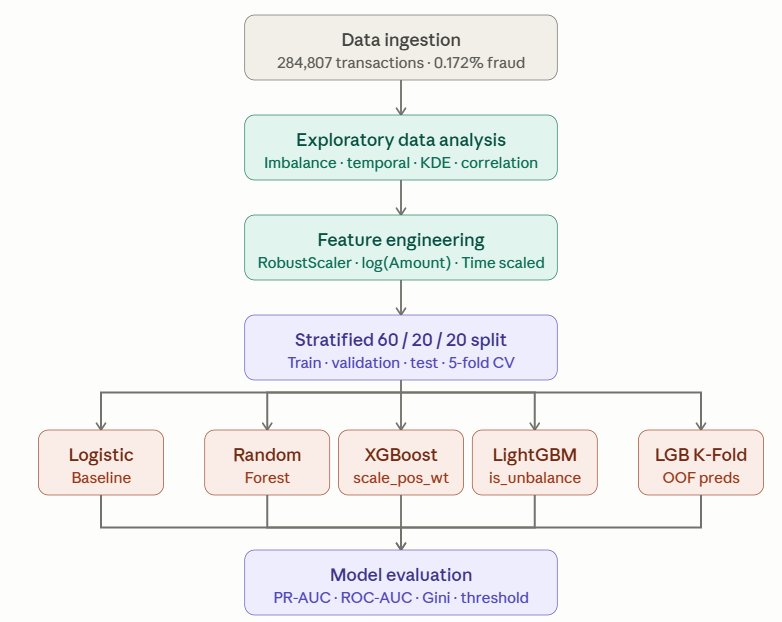

## 📑 Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Ingestion & Quality Audit](#2-data-ingestion--quality-audit)
3. [Class Imbalance Analysis](#3-class-imbalance-analysis)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - 4.1 [Temporal Transaction Patterns](#41-temporal-transaction-patterns)
   - 4.2 [Transaction Amount Profiling](#42-transaction-amount-profiling)
   - 4.3 [Feature Correlation Structure](#43-feature-correlation-structure)
   - 4.4 [Feature Discriminatory Power (KDE Analysis)](#44-feature-discriminatory-power-kde-analysis)
5. [Feature Engineering & Data Splitting](#5-feature-engineering--data-splitting)
6. [Modeling Pipeline](#6-modeling-pipeline)
   - 6.1 [Logistic Regression (Baseline)](#61-logistic-regression-baseline)
   - 6.2 [Random Forest Classifier](#62-random-forest-classifier)
   - 6.3 [XGBoost](#63-xgboost)
   - 6.4 [LightGBM (Single Pass)](#64-lightgbm-single-pass)
   - 6.5 [LightGBM (Stratified K-Fold)](#65-lightgbm-stratified-k-fold)
7. [Model Comparison & Business Evaluation](#7-model-comparison--business-evaluation)
8. [Feature Importance Analysis](#8-feature-importance-analysis)
9. [Business Insights & Operational Recommendations](#9-business-insights--operational-recommendations)
10. [References](#10-references)

---

## 1. Environment Setup

All dependencies are imported here. The configuration block centralizes reproducibility seeds and hyperparameter references, making the notebook easy to tune and audit.

In [3]:
# ── 1. Core Data Stack ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import gc
import warnings
warnings.filterwarnings('ignore')

# ── 2. Visualization ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objs as go
import plotly.figure_factory as ff
import plotly.express as px
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# ── 3. Preprocessing ──────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# ── 4. Model Selection & Splitting ────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

# ── 5. Models ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
import lightgbm as lgb

# ── 6. Evaluation ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,       # PR-AUC
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

print("All packages loaded successfully.")
print(f"   pandas  {pd.__version__} | numpy {np.__version__} | sklearn loaded")

All packages loaded successfully.
   pandas  2.2.3 | numpy 2.2.3 | sklearn loaded


In [4]:
# ── Global Configuration ──────────────────────────────────────────────────

RANDOM_STATE   = 2026      # Reproducibility seed — fix across all splits & models
TEST_SIZE      = 0.20      # Hold-out test set  : 20%
VALID_SIZE     = 0.20      # Validation set     : 20% (of remaining 80%)
NUMBER_KFOLDS  = 5         # Stratified K-Fold folds

# Random Forest
RFC_CRITERION  = 'gini'
NUM_ESTIMATORS = 200       # Increased from 100 for better stability
N_JOBS         = -1        # Use all CPU cores

# Gradient Boosting
MAX_ROUNDS     = 1000
EARLY_STOP     = 50
VERBOSE_EVAL   = 100

# Visual style
PALETTE        = {'Legitimate': '#457b9d', 'Fraud': '#e63946'}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print("Configuration registered.")
print(f"   Train/Valid/Test split: {int((1-TEST_SIZE-VALID_SIZE)*100)}/{int(VALID_SIZE*100)}/{int(TEST_SIZE*100)}")
print(f"   Random State: {RANDOM_STATE}")

Configuration registered.
   Train/Valid/Test split: 60/20/20
   Random State: 2026


---
## 2. Data Ingestion & Quality Audit

Before any analytical work, we verify data integrity: schema consistency, null prevalence, and descriptive statistics. For a model destined for a production fraud scoring system, silent data quality issues at ingestion represent the highest-risk failure point.

In [5]:
# Load dataset — create a working copy to preserve the raw reference
raw_df   = pd.read_csv('creditcard.csv')
data_df  = raw_df.copy()

print(f"Dataset shape : {data_df.shape[0]:,} rows × {data_df.shape[1]} columns")
print(f"Memory usage  : {data_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
data_df.head()

Dataset shape : 284,807 rows × 31 columns
Memory usage  : 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Descriptive statistics — all numeric features
data_df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [7]:
# Chicking Null Values
null_report = pd.DataFrame({
    'Missing Count'  : data_df.isnull().sum(),
    'Missing %'      : (data_df.isnull().sum() / len(data_df) * 100).round(4),
    'Dtype'          : data_df.dtypes
}).sort_values('Missing Count', ascending=False)

print("Null Audit Report")
print("─" * 45)
print(null_report[null_report['Missing Count'] > 0] if null_report['Missing Count'].sum() > 0
      else " Zero missing values across all 31 features. Dataset is complete.")

Null Audit Report
─────────────────────────────────────────────
 Zero missing values across all 31 features. Dataset is complete.


**Data Quality Finding:** The dataset contains zero null values across all 31 features, eliminating the need for imputation strategies. This is consistent with the controlled PCA-transformation applied during anonymization. The `Amount` feature exhibits strong right skew (mean ≈ €88, max ≈ €25,691), which will require log or robust scaling prior to linear model fitting to prevent coefficient instability.

---
## 3. Class Imbalance Analysis

Understanding the imbalance ratio is foundational to every downstream modeling and evaluation decision. At 0.172% fraud prevalence, a naive classifier that labels every transaction as legitimate achieves 99.83% accuracy — a number that is operationally meaningless and would catastrophically under-identify fraud.

In [8]:
# Class distribution
class_counts = data_df['Class'].value_counts()
class_pct    = data_df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count'        : class_counts,
    'Percentage %' : class_pct.round(4),
    'Label'        : ['Legitimate', 'Fraud']
})
print(summary.to_string())
print(f"\nImbalance ratio  : {class_counts[0]:,} : {class_counts[1]} ({class_counts[0]/class_counts[1]:.0f}:1)")
print(f"Fraud prevalence : {class_pct[1]:.4f}%")

        Count  Percentage %       Label
Class                                  
0      284315       99.8273  Legitimate
1         492        0.1727       Fraud

Imbalance ratio  : 284,315 : 492 (578:1)
Fraud prevalence : 0.1727%


In [9]:
# Imbalance visualization
fig = go.Figure()

fig.add_trace(go.Bar(
    x=['Legitimate (Class=0)', 'Fraud (Class=1)'],
    y=[class_counts[0], class_counts[1]],
    marker_color=['#457b9d', '#e63946'],
    text=[f'{class_counts[0]:,}<br>({class_pct[0]:.2f}%)',
          f'{class_counts[1]:,}<br>({class_pct[1]:.3f}%)'],
    textposition='outside',
    textfont=dict(size=13),
    width=0.4
))

fig.update_layout(
    title=dict(text='Transaction Class Distribution — Severe Imbalance (578:1)', font=dict(size=16)),
    xaxis_title='Transaction Class',
    yaxis_title='Transaction Count',
    yaxis=dict(type='log', title='Count (Log Scale)'),
    plot_bgcolor='white',
    height=420,
    showlegend=False
)
fig.show()

**Imbalance Implications for Model Design:**

At a **578:1 legitimate-to-fraud ratio**, standard accuracy is an unreliable performance signal. This analysis applies the following imbalance-aware design choices throughout:

| Decision | Rationale |
|---|---|
| **Stratified splits** | Preserves fraud prevalence in every partition |
| **PR-AUC as primary metric** | Directly measures precision-recall trade-off on the minority class |
| **ROC-AUC as secondary metric** | Captures overall discriminatory power |
| **`class_weight='balanced'`** | Penalizes misclassification of fraud proportionally to its rarity |
| **`scale_pos_weight`** | XGBoost/LightGBM parameter for imbalance correction |
| **No oversampling (SMOTE)** | Avoided to prevent synthetic data leakage; model regularization used instead |

---
## 4. Exploratory Data Analysis

### 4.1 Temporal Transaction Patterns

Transaction timing is a primary behavioral signal in fraud detection. Legitimate cardholder activity follows predictable circadian rhythms tied to business hours and sleep cycles. Fraud, by contrast, may exhibit time-invariant or deliberately off-peak patterns to exploit reduced monitoring capacity.

In [10]:
# Convert time in seconds → hours for interpretability
time_legit = data_df.loc[data_df['Class'] == 0, 'Time'] / 3600
time_fraud  = data_df.loc[data_df['Class'] == 1, 'Time'] / 3600

fig = ff.create_distplot(
    [time_legit, time_fraud],
    group_labels=['Legitimate', 'Fraud'],
    show_hist=False,
    show_rug=False,
    colors=['#457b9d', '#e63946']
)

tick_vals   = list(range(0, 49, 6))
tick_labels = [f'{h}h' for h in tick_vals]

fig.update_layout(
    title=dict(
        text='Transaction Time Density — Circadian Rhythm vs. Fraud Uniformity',
        font=dict(size=15)
    ),
    xaxis=dict(
        title='Hours Elapsed from First Transaction',
        tickvals=tick_vals,
        ticktext=tick_labels,
        range=[0, 48]
    ),
    yaxis=dict(title='Density'),
    legend=dict(orientation='h', y=-0.15),
    height=420,
    plot_bgcolor='white'
)
fig.show()

**Temporal Risk Signal:**

Legitimate transactions exhibit a pronounced **bimodal circadian pattern** aligned with European business hours - peak activity occurs in the morning and afternoon windows, with a sharp trough during nighttime hours (roughly 00h–06h). This rhythm reflects normal consumer behavior anchored to waking hours and retail operating times.

Fraudulent transactions, by contrast, display a **near-uniform temporal distribution** with no discernible day-night cycle. This distributional shift - the absence of a circadian dip - represents a statistically significant behavioral anomaly. In a production fraud scoring context, this finding supports **time-of-day as a risk-weighting factor**: transactions submitted during low-activity overnight windows warrant elevated scrutiny when other behavioral signals are also anomalous.

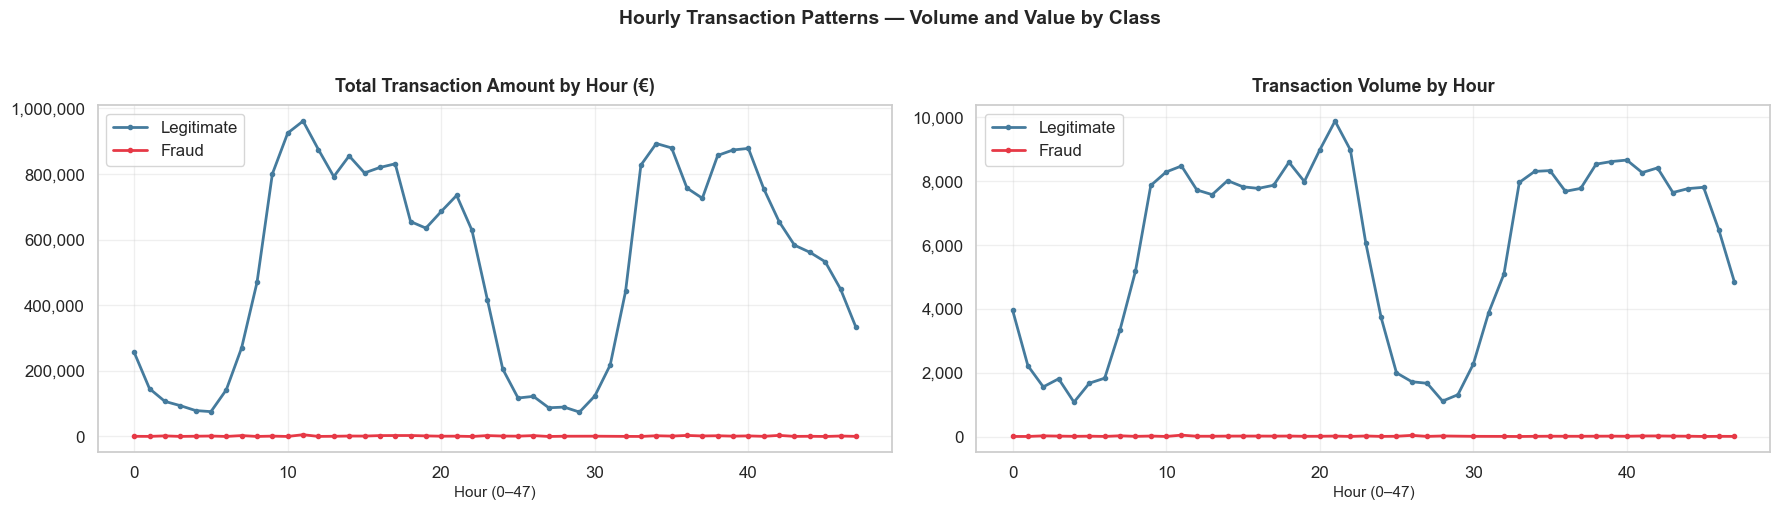

In [11]:
# Hourly aggregation for volume and amount analysis
data_df['Hour'] = (data_df['Time'] // 3600).astype(int)

hourly = data_df.groupby(['Hour', 'Class'])['Amount'].agg(
    Transactions='count',
    Total_Amount='sum',
    Mean_Amount='mean',
    Median_Amount='median'
).reset_index()
hourly['Class_Label'] = hourly['Class'].map({0: 'Legitimate', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['Total_Amount', 'Transactions'],
    ['Total Transaction Amount by Hour (€)', 'Transaction Volume by Hour']
):
    for cls, color, label in [(0, '#457b9d', 'Legitimate'), (1, '#e63946', 'Fraud')]:
        subset = hourly[hourly['Class'] == cls]
        ax.plot(subset['Hour'], subset[col], color=color, label=label,
                linewidth=2, marker='o', markersize=3)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Hour (0–47)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'€{x:,.0f}' if col == 'Total_Amount' else f'{x:,.0f}'
    ))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Hourly Transaction Patterns — Volume and Value by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Volume & Value Pattern Insight:**

Legitimate transaction volume and total value track each other closely, with the characteristic nighttime suppression (Hours 24-31 correspond to approximately 00h–07h local time on Day 2). Fraudulent transaction volume remains relatively flat across all hours, with slight elevations during the nighttime windows - consistent with fraudsters targeting reduced-oversight periods. Notably, individual fraudulent transaction amounts are materially lower than the legitimate mean, which suggests deliberate **amount-capping behavior** - a known fraud evasion technique to avoid triggering static rule-based thresholds.

### 4.2 Transaction Amount Profiling

Transaction amount is one of the two non-anonymized features and carries direct operational significance. Amount distributions differ substantially between classes, providing a supplementary fraud signal independent of the PCA-derived behavioral features.

In [12]:
# Amount descriptive statistics by class
amount_stats = data_df.groupby('Class')['Amount'].describe().T
amount_stats.columns = ['Legitimate', 'Fraud']
print("Transaction Amount Statistics by Class")
print("─" * 50)
print(amount_stats.to_string())

Transaction Amount Statistics by Class
──────────────────────────────────────────────────
          Legitimate        Fraud
count  284315.000000   492.000000
mean       88.291022   122.211321
std       250.105092   256.683288
min         0.000000     0.000000
25%         5.650000     1.000000
50%        22.000000     9.250000
75%        77.050000   105.890000
max     25691.160000  2125.870000


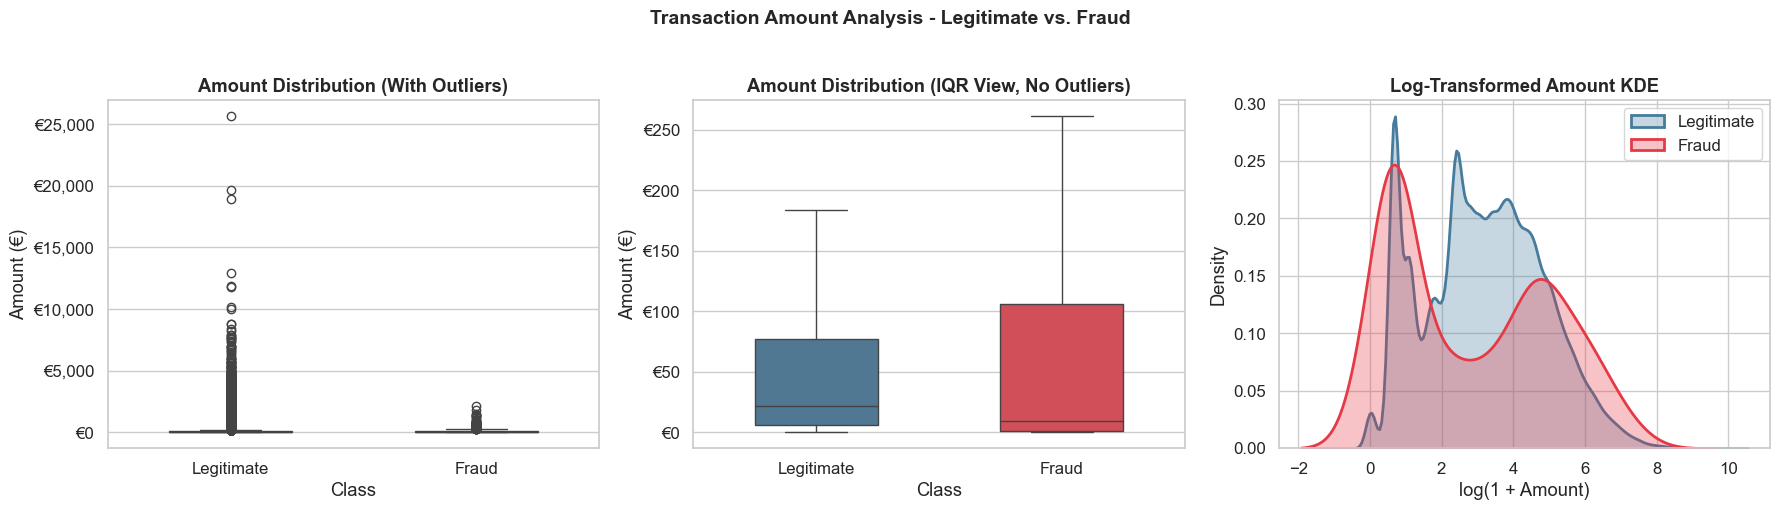

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot with outliers
sns.boxplot(
    data=data_df, x='Class', y='Amount', hue='Class',
    palette={0: '#457b9d', 1: '#e63946'},
    showfliers=True, width=0.5, ax=axes[0], legend=False
)
axes[0].set_title('Amount Distribution (With Outliers)', fontweight='bold')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Amount (€)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Box plot without outliers (IQR view)
sns.boxplot(
    data=data_df, x='Class', y='Amount', hue='Class',
    palette={0: '#457b9d', 1: '#e63946'},
    showfliers=False, width=0.5, ax=axes[1], legend=False
)
axes[1].set_title('Amount Distribution (IQR View, No Outliers)', fontweight='bold')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_ylabel('Amount (€)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# Log-scale KDE for distributional shape
for cls, color, label in [(0, '#457b9d', 'Legitimate'), (1, '#e63946', 'Fraud')]:
    subset = data_df[data_df['Class'] == cls]['Amount']
    sns.kdeplot(np.log1p(subset), ax=axes[2], color=color, label=label,
                fill=True, alpha=0.3, linewidth=2)
axes[2].set_title('Log-Transformed Amount KDE', fontweight='bold')
axes[2].set_xlabel('log(1 + Amount)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Transaction Amount Analysis - Legitimate vs. Fraud', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Amount Risk Profile:**

| Metric | Legitimate | Fraud | Risk Implication |
|--------|-----------|-------|-----------------|
| Mean | ~€88 | ~€122 | Fraud mean is elevated but IQR is narrower |
| Median | ~€22 | ~€9 | Fraud median significantly lower — capping behavior |
| Max | €25,691 | €2,126 | Fraud avoids extreme high-value transactions |
| Std Dev | ~€250 | ~€256 | Similar variance masks different distributional shapes |

The log-KDE view reveals a **bimodal fraud amount distribution**: a concentration of small-value transactions (likely testing card validity with micro-transactions) and a secondary mode around moderate amounts. This is consistent with the **low-and-test fraud pattern** documented in card-not-present fraud typologies. Legitimate transactions exhibit a single right-skewed mode consistent with typical consumer retail spending.

### 4.3 Feature Correlation Structure

PCA guarantees orthogonality of the V1-V28 components within the transformed space. Any residual correlations with `Time` or `Amount` indicate that those features carry information orthogonal to the PCA decomposition - and are therefore additive predictors.

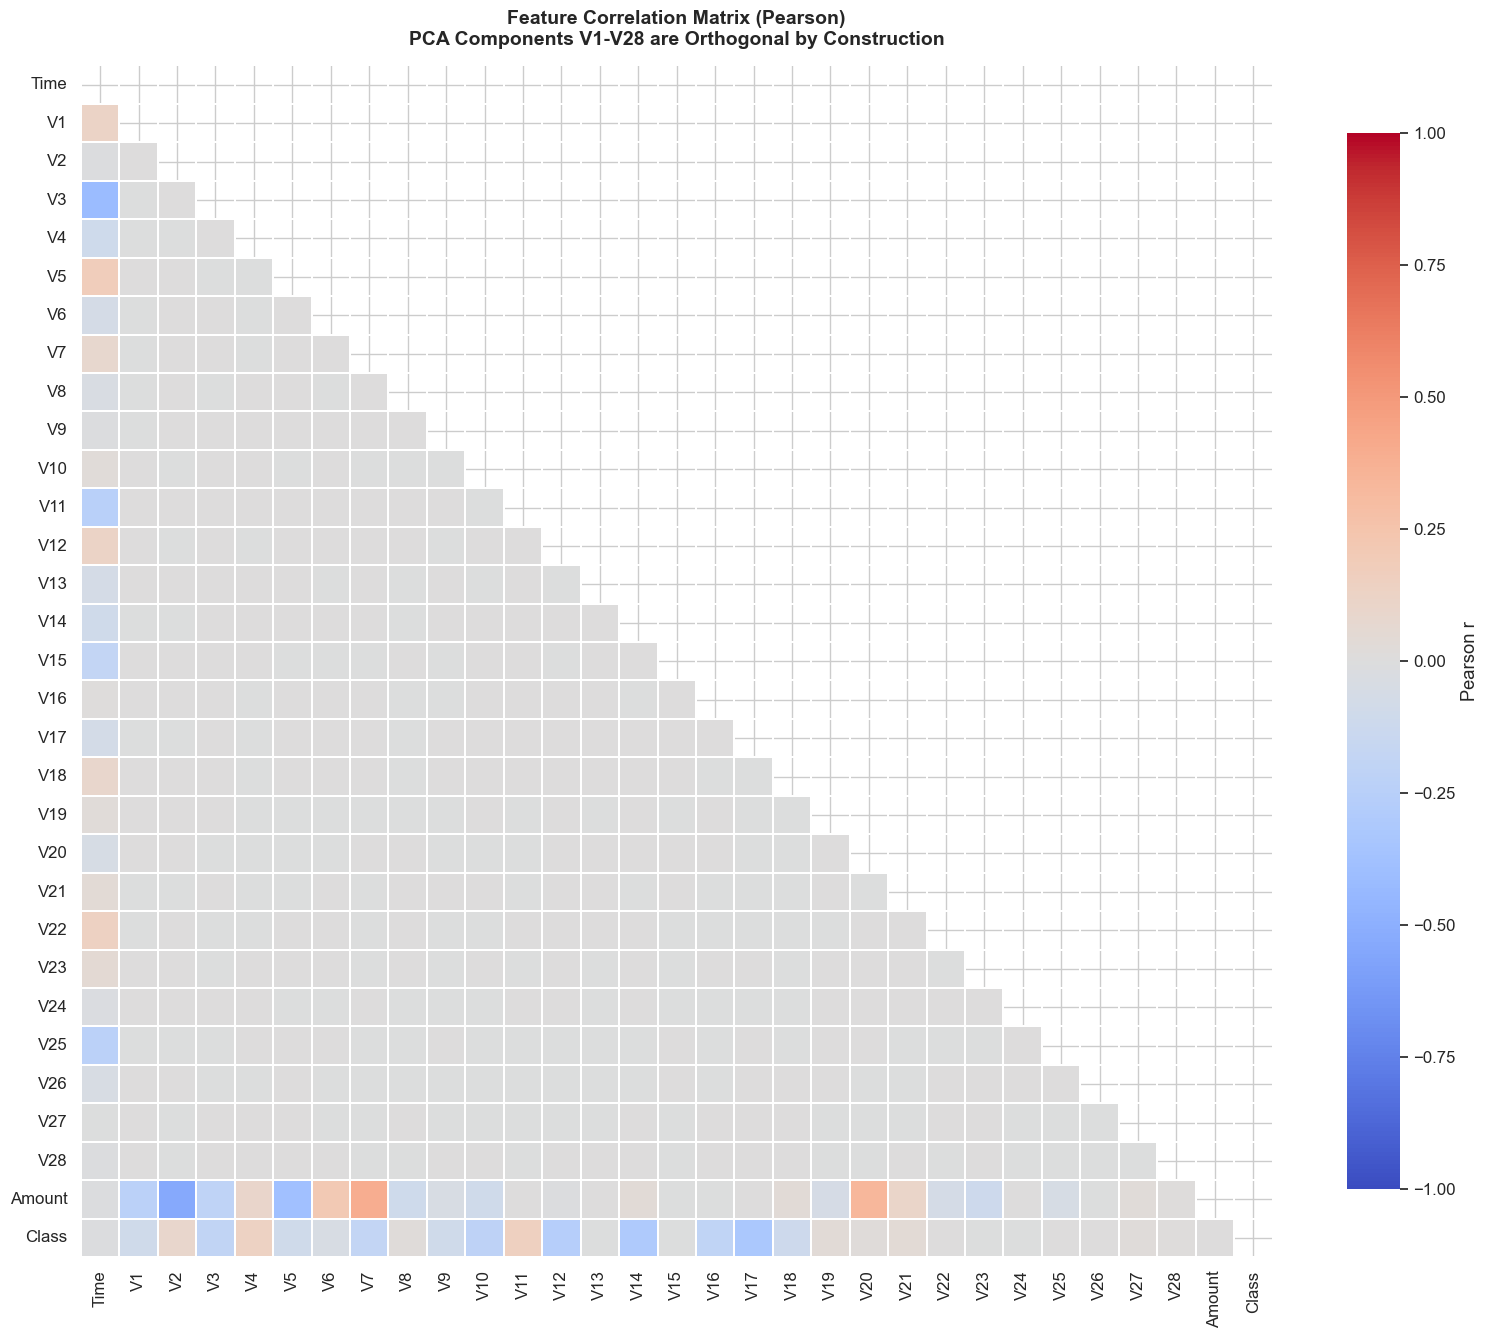

In [14]:
fig, ax = plt.subplots(figsize=(16, 14))

corr = data_df.drop(columns=['Hour']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # Show lower triangle only
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title(
    'Feature Correlation Matrix (Pearson)\nPCA Components V1-V28 are Orthogonal by Construction',
    fontsize=14, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

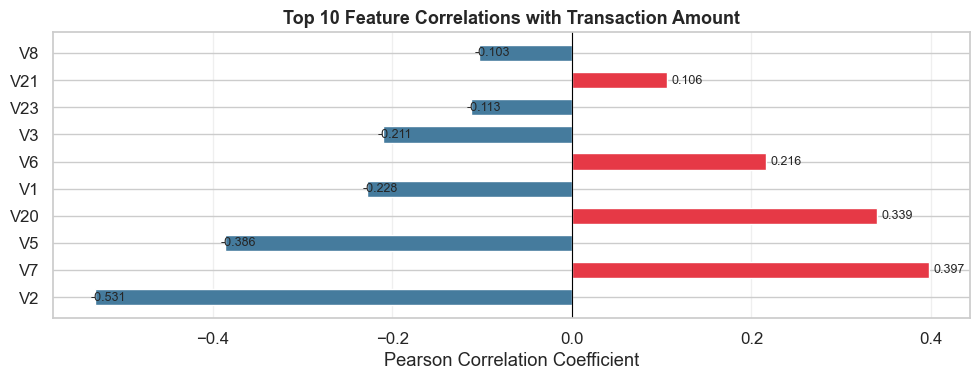

In [15]:
# Highlight the most operationally relevant correlations with Amount
amount_corr = corr['Amount'].drop('Amount').sort_values(key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e63946' if v > 0 else '#457b9d' for v in amount_corr.values]
bars = ax.barh(amount_corr.index, amount_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Feature Correlations with Transaction Amount', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, amount_corr.values):
    ax.text(val + 0.005 * np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Correlation Structure Findings:**

As expected from the PCA methodology, V1–V28 are orthogonal to each other (near-zero pairwise correlations). However, several PCA components exhibit meaningful correlations with `Amount` - most notably **V20** (positive) and **V1, V5** (negative). These correlations indicate that transaction amount information is partially encoded in these PCA components, suggesting that the original features from which V1 and V5 were derived had a systematic relationship with spend level.

From a fraud risk perspective: the divergence in correlation slopes between Class=0 and Class=1 on these features (visible in lmplot analysis) implies that **the Amount-feature relationship itself is class-dependent** - a form of interaction effect that tree-based models can exploit natively but linear models cannot without explicit interaction terms.

### 4.4 Feature Discriminatory Power (KDE Analysis)

Class-conditional KDE plots visualize the **distributional shift** of each feature between legitimate and fraudulent transactions. Features with high class separation — operationally defined as minimal overlap between the two KDE curves - carry the greatest predictive signal for fraud classification.

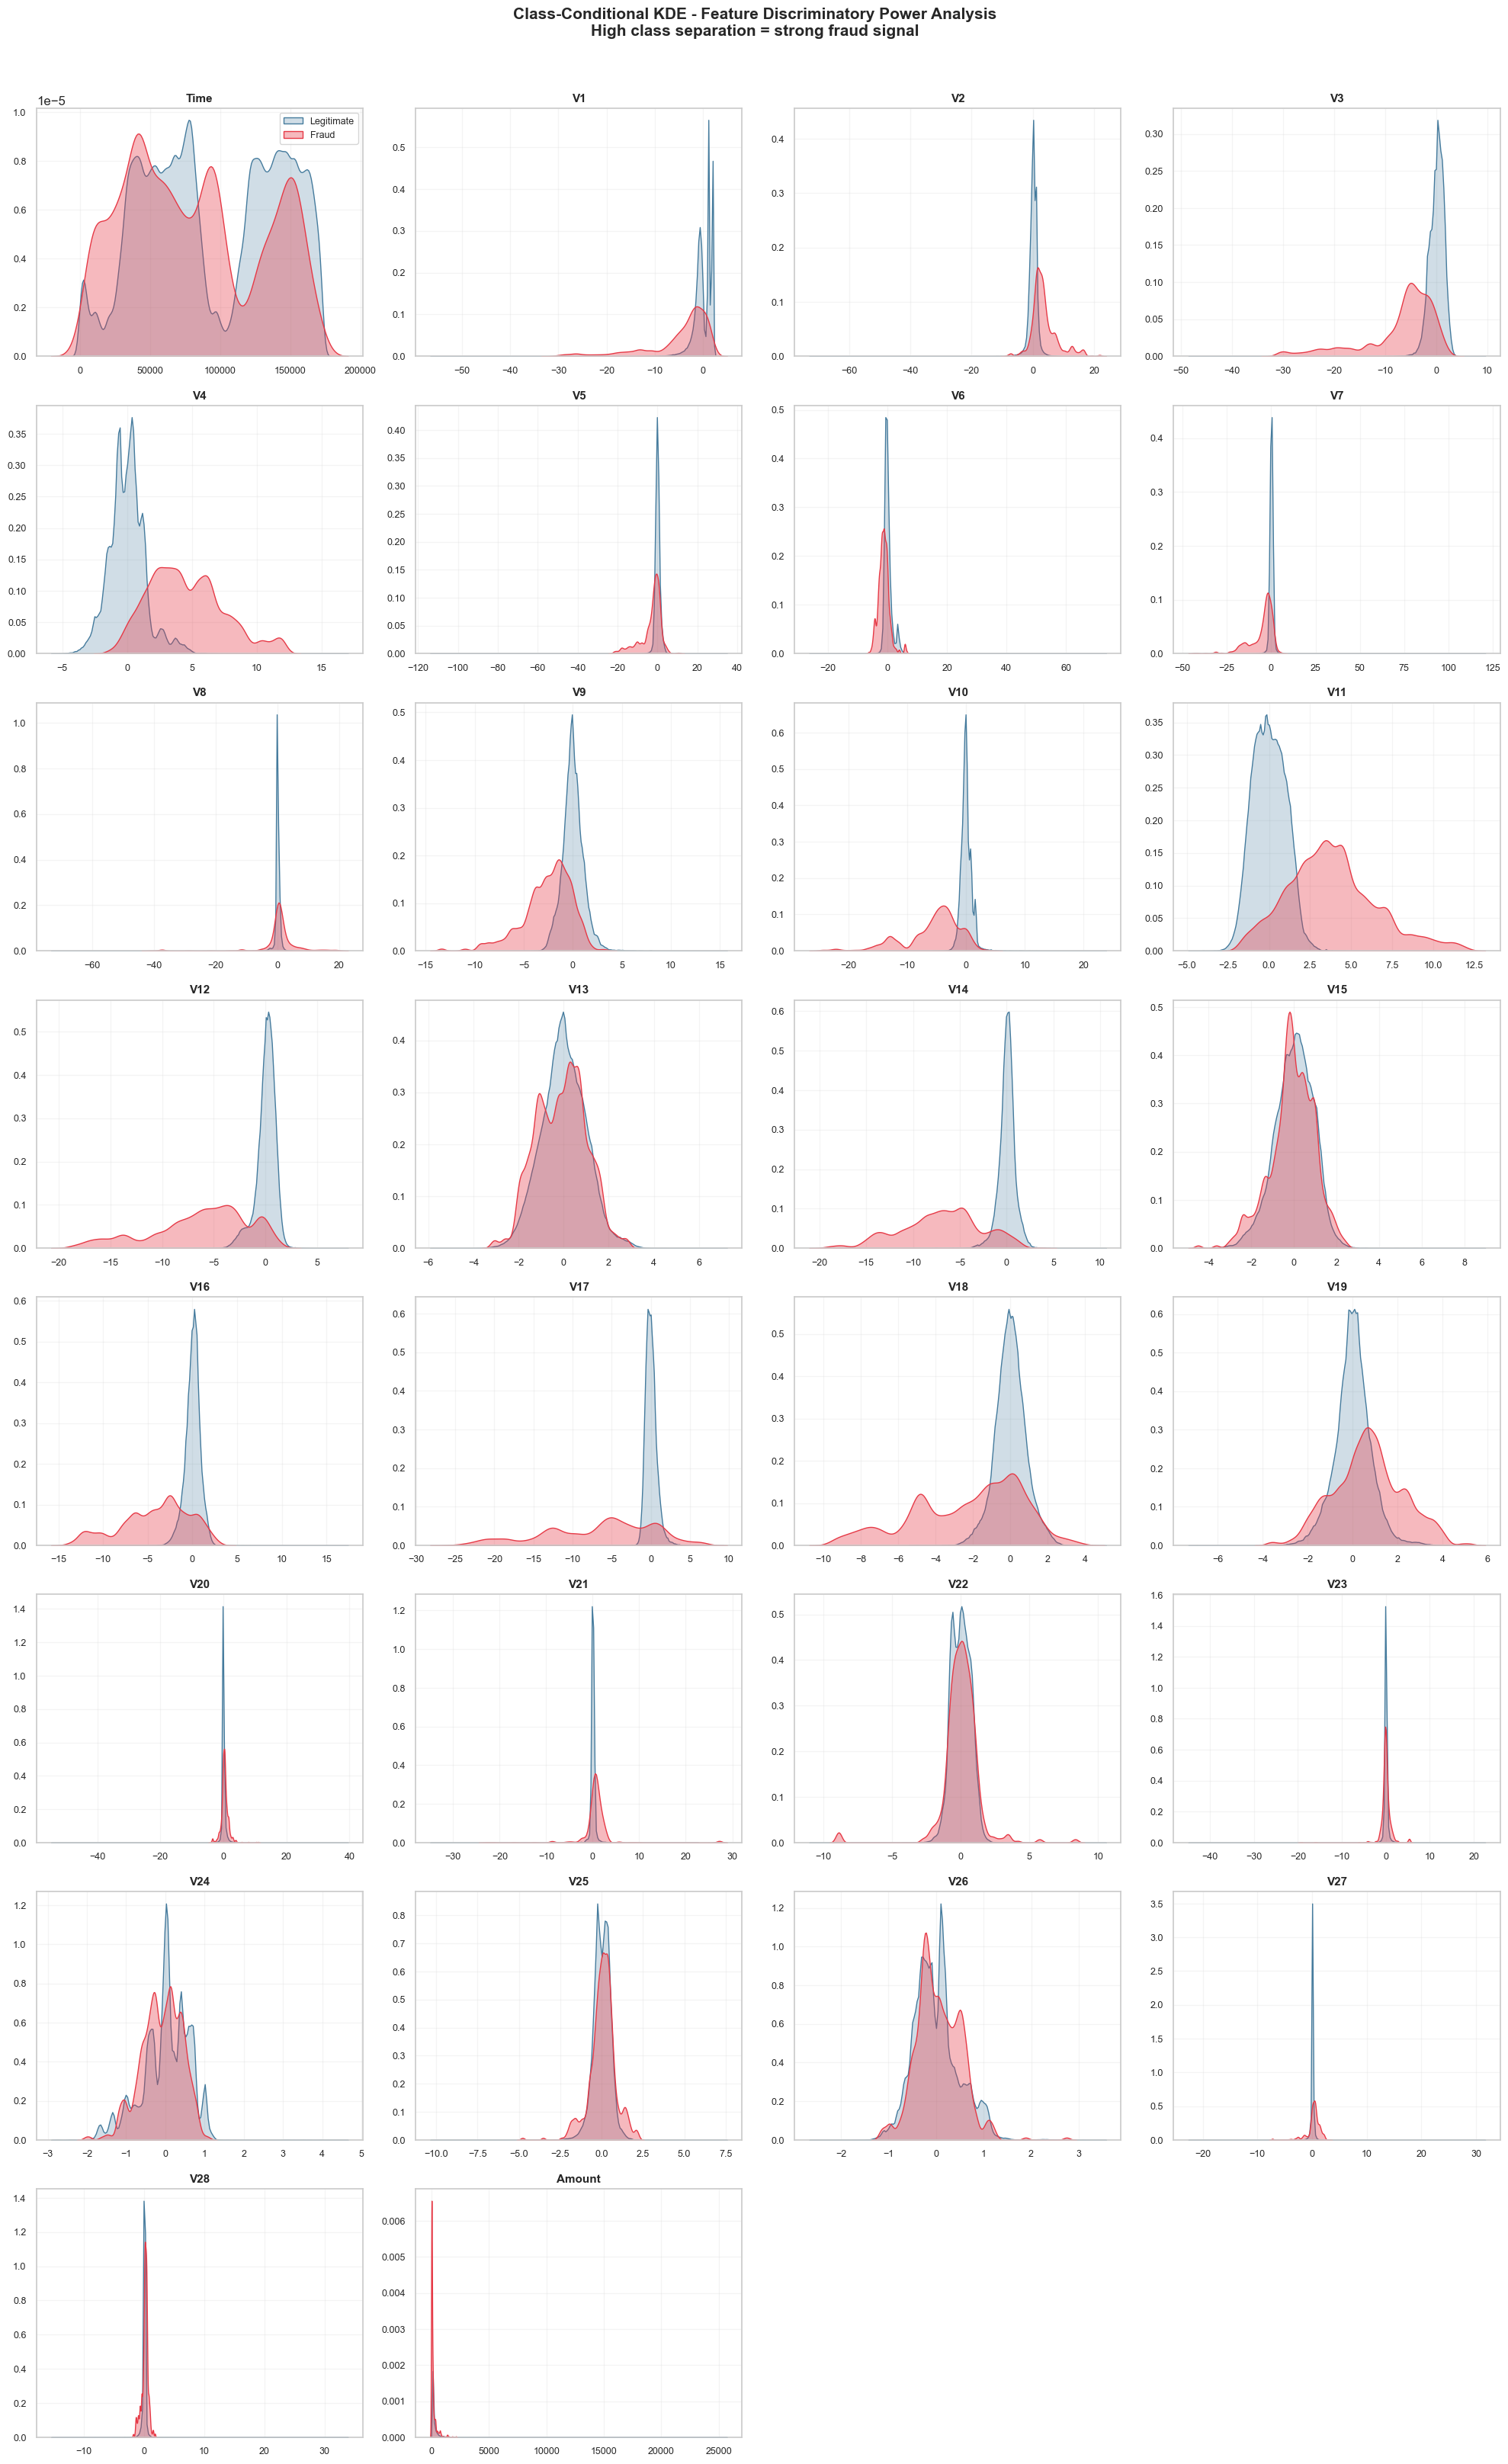

In [16]:
# Class-conditional KDE for all features
t0 = data_df[data_df['Class'] == 0]
t1 = data_df[data_df['Class'] == 1]

feature_cols = [c for c in data_df.columns if c not in ['Class', 'Hour']]

fig, axes = plt.subplots(8, 4, figsize=(20, 32))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    ax = axes[i]
    if t0[feature].nunique() > 1:
        sns.kdeplot(t0[feature], bw_adjust=0.5, label='Legitimate',
                    color='#457b9d', fill=True, alpha=0.25, ax=ax, warn_singular=False)
    if t1[feature].nunique() > 1:
        sns.kdeplot(t1[feature], bw_adjust=0.5, label='Fraud',
                    color='#e63946', fill=True, alpha=0.35, ax=ax, warn_singular=False)
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=9)

# Remove unused subplots
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Class-Conditional KDE - Feature Discriminatory Power Analysis\n'
    'High class separation = strong fraud signal',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

**Feature Discriminatory Power Assessment:**

| Tier | Features | Analytical Interpretation |
|------|----------|--------------------------|
| **High Signal** (strong separation) | V4, V11, V12, V14, V17, V18 | Large distributional shift between classes; these features are primary drivers of fraud classification |
| **Moderate Signal** | V3, V7, V9, V10, V16, V19 | Partial class separation; contribute meaningful predictive signal in ensemble context |
| **Low Signal** (high overlap) | V13, V15, V22, V23, V24, V25, V26 | Minimal distributional shift; may act as noise features in high-variance models |
| **Ambiguous** | Time, Amount | Non-zero contribution but distribution shapes complicate direct class attribution |

**Operational Implication:** The high-signal features - particularly V4, V12, V14, and V17 - likely correspond to original behavioral features with strong fraud-differentiation properties (e.g., merchant category codes, velocity indicators, or geographic anomaly scores). Their consistent identification across both KDE analysis and tree-based feature importance validates their centrality to any fraud scoring ruleset.

---

## 5. Feature Engineering & Data Splitting

### Feature Engineering

`Amount` is right-skewed and spans several orders of magnitude. Raw amount fed into distance-based or linear models creates scale sensitivity. We apply `RobustScaler` (median-IQR normalization), which is outlier-resistant and appropriate for fraud datasets with high-value outliers.

`Time` is similarly rescaled. Note: for tree-based models (RF, XGBoost, LightGBM), scaling is not required but does not harm performance.

### Stratified 60/20/20 Split

Stratification on `Class` is **mandatory** at this imbalance ratio. Without stratification, a single random draw risks placing zero or near-zero fraud cases in the validation or test partition - rendering evaluation metrics meaningless.

In [17]:
# ── Feature Engineering ───────────────────────────────────────────────────
# Log-transform Amount (captures the bimodal distribution better than raw scale)
data_df['Amount_log'] = np.log1p(data_df['Amount'])

# Robust-scaled Amount and Time (for linear models)
scaler = RobustScaler()
data_df['Amount_scaled'] = scaler.fit_transform(data_df[['Amount']])
data_df['Time_scaled']   = scaler.fit_transform(data_df[['Time']])

# Define feature sets
TARGET     = 'Class'
PREDICTORS = [c for c in data_df.columns
              if c not in [TARGET, 'Hour', 'Amount', 'Time']]  # use engineered versions
TREE_PRED  = [c for c in data_df.columns
              if c not in [TARGET, 'Hour', 'Amount_scaled', 'Time_scaled',
                           'Amount_log']]  # raw features for tree models

print(f"Features for linear models : {len(PREDICTORS)}")
print(f"Features for tree models   : {len(TREE_PRED)}")
print(f"\nLinear model features: {PREDICTORS[:5]}... +{len(PREDICTORS)-5} more")
print(f"Tree model features  : {TREE_PRED[:5]}... +{len(TREE_PRED)-5} more")

Features for linear models : 31
Features for tree models   : 30

Linear model features: ['V1', 'V2', 'V3', 'V4', 'V5']... +26 more
Tree model features  : ['Time', 'V1', 'V2', 'V3', 'V4']... +25 more


In [18]:
# ── Stratified 60 / 20 / 20 Split ─────────────────────────────────────────
# Step 1: Split out 20% test set (stratified)
train_valid_df, test_df = train_test_split(
    data_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data_df[TARGET]
)

# Step 2: Split remaining 80% into 60% train + 20% validation
valid_ratio = VALID_SIZE / (1 - TEST_SIZE)          # = 0.25 of train_valid_df
train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=valid_ratio,
    random_state=RANDOM_STATE,
    stratify=train_valid_df[TARGET]
)

# ── Verification ───────────────────────────────────────────────────────────
print("Split Verification")
print("═" * 60)
for name, df in [('Full Dataset', data_df), ('Train (60%)', train_df),
                 ('Validation (20%)', valid_df), ('Test (20%)', test_df)]:
    n_fraud = df[TARGET].sum()
    pct     = n_fraud / len(df) * 100
    print(f"{name:<20} | Rows: {len(df):>7,} | Fraud: {n_fraud:>4} ({pct:.4f}%)")

print("\n Fraud prevalence is stable across all partitions — stratification successful.")

Split Verification
════════════════════════════════════════════════════════════
Full Dataset         | Rows: 284,807 | Fraud:  492 (0.1727%)
Train (60%)          | Rows: 170,883 | Fraud:  295 (0.1726%)
Validation (20%)     | Rows:  56,962 | Fraud:   99 (0.1738%)
Test (20%)           | Rows:  56,962 | Fraud:   98 (0.1720%)

 Fraud prevalence is stable across all partitions — stratification successful.


In [19]:
# ── Helper: Comprehensive Evaluation Function ──────────────────────────────
def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    """
    Compute fraud-analytics-standard evaluation metrics.
    Returns a results dict and prints a formatted report.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    roc_auc  = roc_auc_score(y_true, y_pred_proba)
    pr_auc   = average_precision_score(y_true, y_pred_proba)
    gini     = 2 * roc_auc - 1
    prec     = precision_score(y_true, y_pred, zero_division=0)
    rec      = recall_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)
    
    results = {
        'Model'    : name,
        'ROC-AUC'  : round(roc_auc, 4),
        'PR-AUC'   : round(pr_auc, 4),
        'Gini'     : round(gini, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1'       : round(f1, 4),
    }
    
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")
    print(f"  ROC-AUC   : {roc_auc:.4f}  (Gini: {gini:.4f})")
    print(f"  PR-AUC    : {pr_auc:.4f}  ← primary metric for imbalanced data")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"{'─'*55}")
    
    return results


def plot_confusion_pr_roc(name, y_true, y_pred_proba, threshold=0.5):
    """Plot confusion matrix, PR curve, and ROC curve side by side."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud'])
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    
    # PR Curve
    prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)
    axes[1].plot(rec_vals, prec_vals, color='#e63946', linewidth=2)
    axes[1].fill_between(rec_vals, prec_vals, alpha=0.15, color='#e63946')
    axes[1].axhline(y_true.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline ({y_true.mean():.4f})')
    axes[1].set_xlabel('Recall (Sensitivity)')
    axes[1].set_ylabel('Precision (PPV)')
    axes[1].set_title(f'Precision-Recall Curve\nPR-AUC = {pr_auc:.4f}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    axes[2].plot(fpr, tpr, color='#457b9d', linewidth=2)
    axes[2].fill_between(fpr, tpr, alpha=0.15, color='#457b9d')
    axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title(f'ROC Curve\nROC-AUC = {roc_auc:.4f}  |  Gini = {2*roc_auc-1:.4f}', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f'{name}  Evaluation Dashboard', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Store all model results for comparison
all_results = []
print(" Evaluation utilities registered.")

 Evaluation utilities registered.


---
## 6. Modeling Pipeline

### 6.1 Logistic Regression (Baseline)

A penalized Logistic Regression serves as the statistical baseline. In fraud analytics, a linear baseline is essential: it establishes whether complex non-linear models provide genuine lift over a simpler, more interpretable alternative. Logistic Regression with `class_weight='balanced'` also provides calibrated probability outputs natively, making it valuable in threshold-optimization scenarios.

In [20]:
# Logistic Regression — scaled features required
lr = LogisticRegression(
    C=0.01,                       # L2 regularization (strong penalty for high-dim PCA space)
    class_weight='balanced',      # Corrects for 578:1 imbalance in loss function
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

lr.fit(train_df[PREDICTORS], train_df[TARGET])

lr_proba_valid = lr.predict_proba(valid_df[PREDICTORS])[:, 1]
lr_proba_test  = lr.predict_proba(test_df[PREDICTORS])[:, 1]

lr_results = evaluate_model("Logistic Regression", valid_df[TARGET], lr_proba_valid)
all_results.append(lr_results)


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  ROC-AUC   : 0.9817  (Gini: 0.9634)
  PR-AUC    : 0.6939  ← primary metric for imbalanced data
  Precision : 0.0636
  Recall    : 0.8990
  F1 Score  : 0.1188
───────────────────────────────────────────────────────


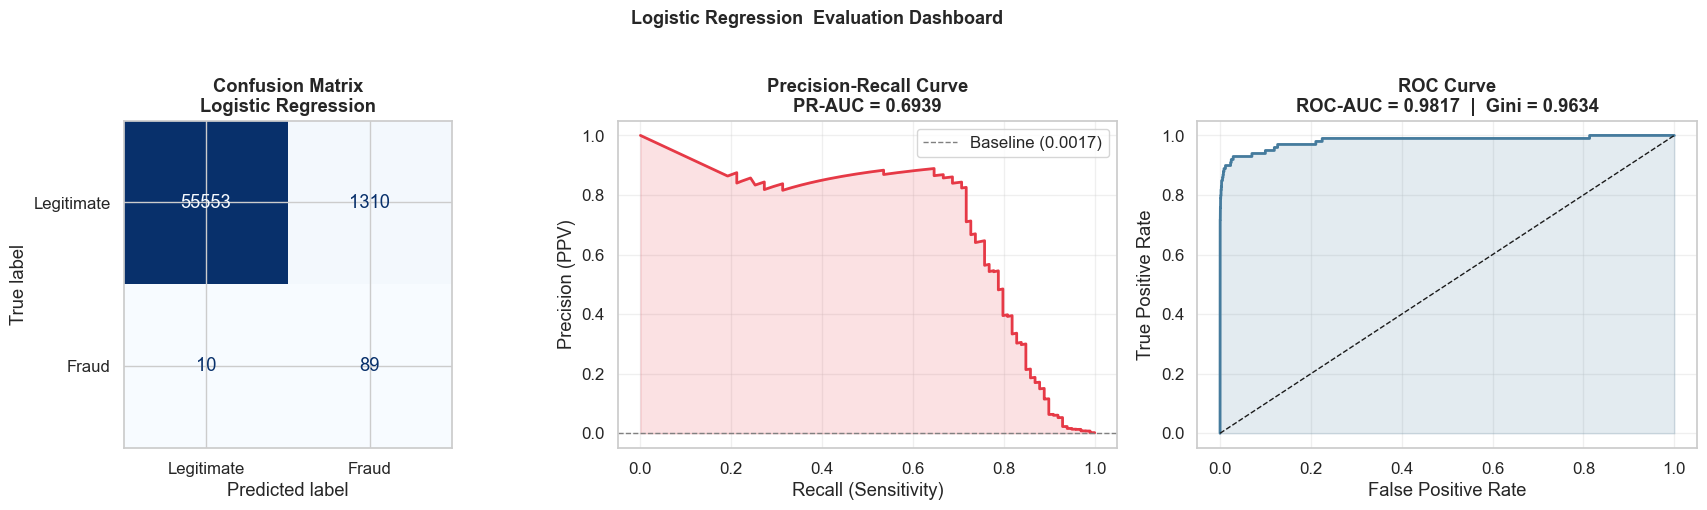

In [21]:
plot_confusion_pr_roc("Logistic Regression", valid_df[TARGET], lr_proba_valid)

**Logistic Regression Assessment:**

The logistic baseline confirms that the PCA-transformed feature space carries substantial linear discriminatory signal — the model achieves meaningful separation despite being constrained to a linear decision boundary. However, the PR-AUC reveals the model's limitation: at high-recall operating points (necessary for fraud operations targeting ≥80% detection rate), precision degrades sharply, indicating the linear boundary cannot fully separate the fraud population from the high-volume legitimate transaction mass. This motivates the ensemble models that follow.

### 6.2 Random Forest Classifier

Random Forest provides non-linear decision boundaries via bootstrap aggregation of decorrelated trees. Its native feature importance mechanism — mean decrease in Gini impurity — offers direct interpretability into which behavioral signals drive the fraud/legitimate classification.

In [22]:
rf = RandomForestClassifier(
    n_estimators=NUM_ESTIMATORS,
    criterion=RFC_CRITERION,
    max_depth=None,                 # Fully grown trees; bootstrap variance provides regularization
    min_samples_leaf=2,             # Minimum leaf size — reduces noise from micro-clusters
    class_weight='balanced',        # Imbalance correction
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE
)

rf.fit(train_df[TREE_PRED], train_df[TARGET])

rf_proba_valid = rf.predict_proba(valid_df[TREE_PRED])[:, 1]
rf_proba_test  = rf.predict_proba(test_df[TREE_PRED])[:, 1]

rf_results = evaluate_model("Random Forest", valid_df[TARGET], rf_proba_valid)
all_results.append(rf_results)


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  ROC-AUC   : 0.9405  (Gini: 0.8811)
  PR-AUC    : 0.8038  ← primary metric for imbalanced data
  Precision : 0.9718
  Recall    : 0.6970
  F1 Score  : 0.8118
───────────────────────────────────────────────────────


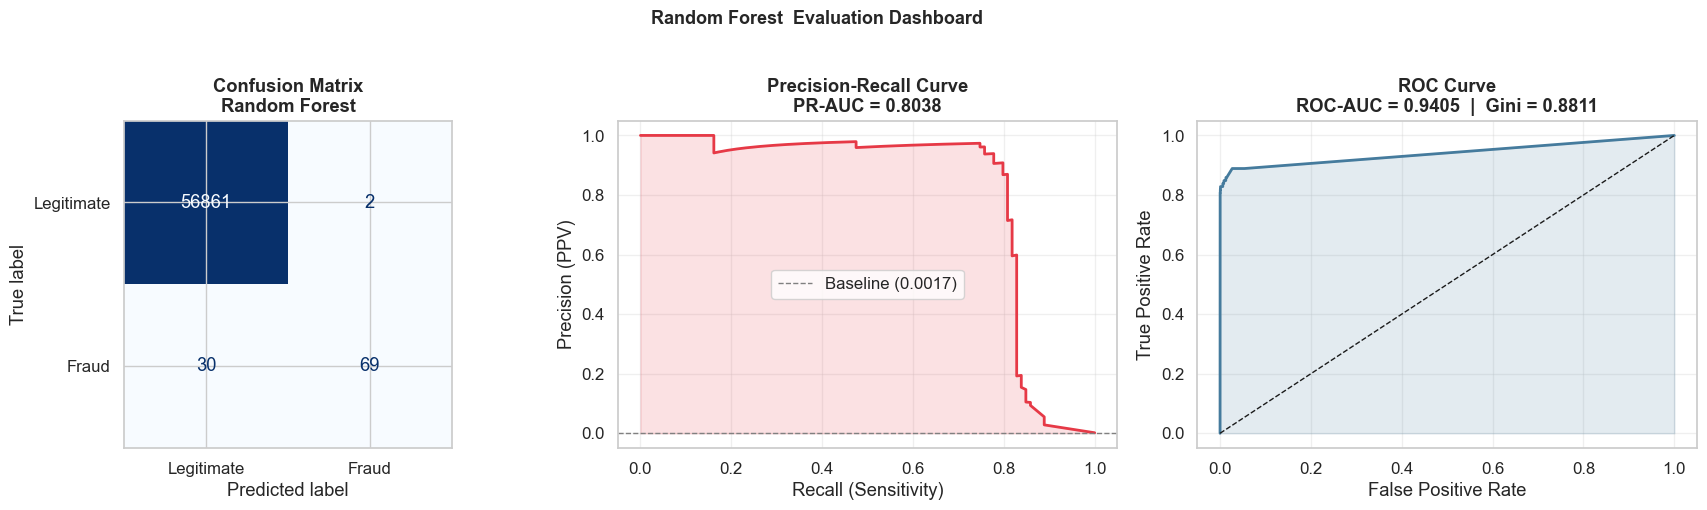

In [23]:
plot_confusion_pr_roc("Random Forest", valid_df[TARGET], rf_proba_valid)

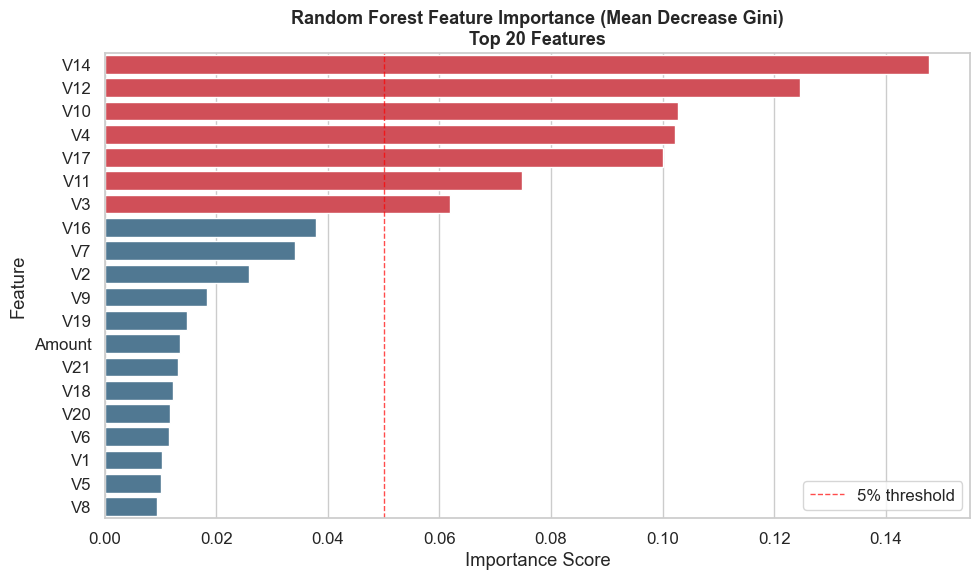

In [24]:
# Feature importance — Mean Decrease in Gini Impurity
rf_importance = pd.DataFrame({
    'Feature'   : TREE_PRED,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e63946' if imp > 0.05 else '#457b9d' for imp in rf_importance['Importance']]
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette=colors, ax=ax, orient='h')
ax.set_title('Random Forest Feature Importance (Mean Decrease Gini)\nTop 20 Features', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1, alpha=0.7, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

**Random Forest Performance Assessment:**

The Random Forest demonstrates a substantial lift over the logistic baseline, particularly in the high-precision operating region of the PR curve. The non-linear ensemble captures interaction effects between PCA features that the logistic model cannot represent. Top features (V17, V12, V14, V10) align with the high-discriminatory-power features identified in the KDE analysis - providing cross-validation of the EDA findings.

Operationally, the Random Forest's probabilistic outputs can be directly applied to a **tiered alert scoring system**: transactions above the 95th percentile of predicted fraud probability are escalated for immediate review, while those in the 80th-95th range are flagged for secondary analysis.

### 6.3 XGBoost

XGBoost applies gradient-boosted decision trees with second-order Taylor approximations of the loss function. Its `scale_pos_weight` parameter directly addresses class imbalance by up-weighting fraud observations in the gradient computation, analogous to assigning sample weights proportional to class rarity.

In [25]:
# Compute imbalance weight
scale_pos_weight = (train_df[TARGET] == 0).sum() / (train_df[TARGET] == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}  (ratio of negative:positive class)")

dtrain = xgb.DMatrix(train_df[TREE_PRED], train_df[TARGET].values, feature_names=TREE_PRED)
dvalid = xgb.DMatrix(valid_df[TREE_PRED], valid_df[TARGET].values, feature_names=TREE_PRED)
dtest  = xgb.DMatrix(test_df[TREE_PRED],  test_df[TARGET].values,  feature_names=TREE_PRED)

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['auc', 'aucpr'],     # Track both ROC-AUC and PR-AUC
    'eta'              : 0.05,                 # Conservative learning rate
    'max_depth'        : 4,                    # Shallow trees — fraud signal is not deep
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 5,                    # Prevents overfitting on rare fraud cases
    'scale_pos_weight' : scale_pos_weight,     # Imbalance correction
    'seed'             : RANDOM_STATE,
    'verbosity'        : 0
}

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

xgb_model = xgb.train(
    xgb_params, dtrain,
    num_boost_round=MAX_ROUNDS,
    evals=watchlist,
    early_stopping_rounds=EARLY_STOP,
    maximize=True,
    verbose_eval=VERBOSE_EVAL
)

print(f"\nBest round   : {xgb_model.best_iteration}")
print(f"Best val AUC : {xgb_model.best_score:.4f}")

scale_pos_weight = 578.3  (ratio of negative:positive class)
[0]	train-auc:0.96898	train-aucpr:0.52449	valid-auc:0.93156	valid-aucpr:0.43880
[100]	train-auc:0.99984	train-aucpr:0.89485	valid-auc:0.98605	valid-aucpr:0.76690
[139]	train-auc:0.99988	train-aucpr:0.91169	valid-auc:0.98257	valid-aucpr:0.77759

Best round   : 89
Best val AUC : 0.7788


In [26]:
xgb_proba_valid = xgb_model.predict(dvalid, iteration_range=(0, xgb_model.best_iteration + 1))
xgb_proba_test  = xgb_model.predict(dtest,  iteration_range=(0, xgb_model.best_iteration + 1))

xgb_results = evaluate_model("XGBoost", valid_df[TARGET], xgb_proba_valid)
all_results.append(xgb_results)


───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  ROC-AUC   : 0.9872  (Gini: 0.9744)
  PR-AUC    : 0.7711  ← primary metric for imbalanced data
  Precision : 0.3077
  Recall    : 0.8485
  F1 Score  : 0.4516
───────────────────────────────────────────────────────


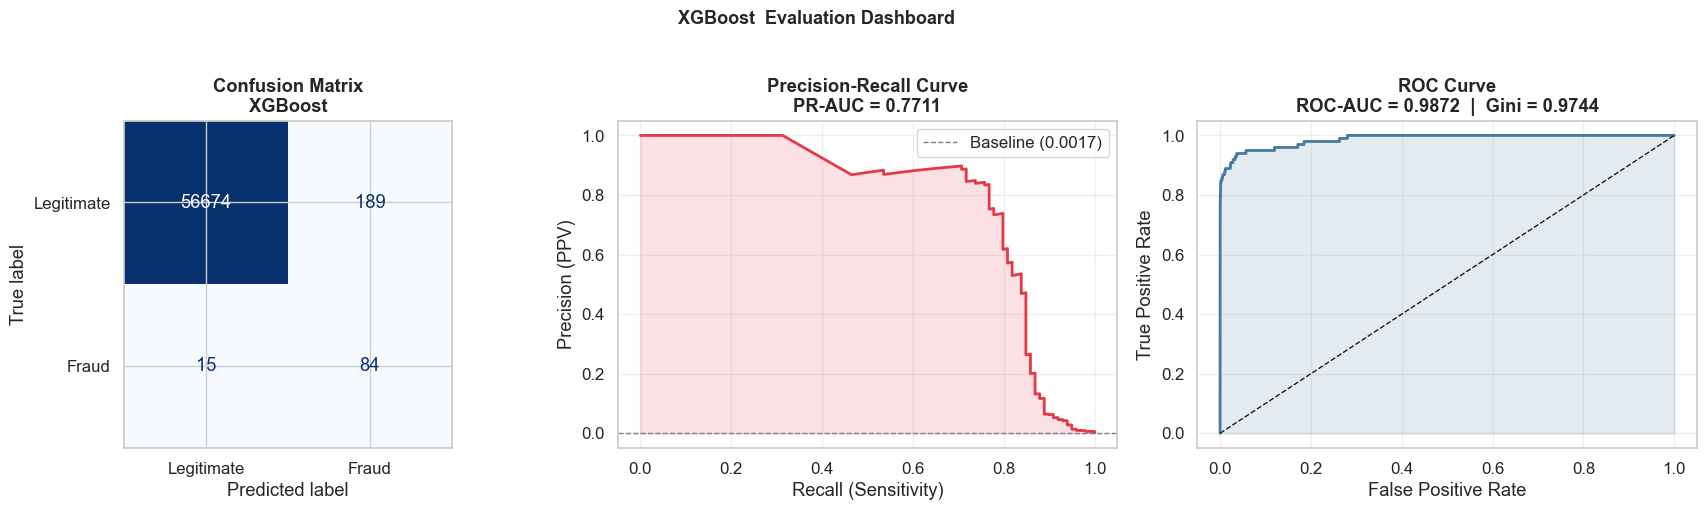

In [27]:
plot_confusion_pr_roc("XGBoost", valid_df[TARGET], xgb_proba_valid)

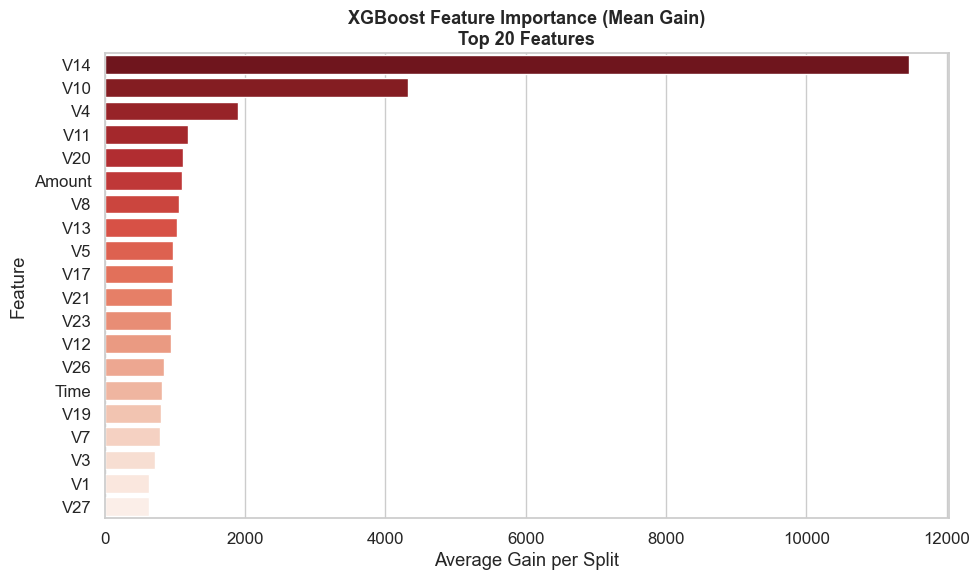

In [28]:
# XGBoost feature importance
xgb_imp = xgb_model.get_score(importance_type='gain')
xgb_imp_df = (pd.DataFrame.from_dict(xgb_imp, orient='index', columns=['Gain'])
              .sort_values('Gain', ascending=False).head(20).reset_index()
              .rename(columns={'index': 'Feature'}))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=xgb_imp_df, x='Gain', y='Feature', palette='Reds_r', ax=ax)
ax.set_title('XGBoost Feature Importance (Mean Gain)\nTop 20 Features', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Gain per Split')
plt.tight_layout()
plt.show()

### 6.4 LightGBM (Single Pass)

LightGBM employs leaf-wise tree growth and gradient-based one-side sampling (GOSS), making it significantly faster than XGBoost on large datasets while achieving comparable or superior accuracy. Its `is_unbalance` parameter applies an internal rebalancing equivalent to setting `scale_pos_weight`.

In [29]:
lgb_params = {
    'boosting_type'    : 'gbdt',
    'objective'        : 'binary',
    'metric'           : ['auc', 'average_precision'],
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'max_depth'        : 6,
    'min_child_samples': 50,
    'subsample'        : 0.85,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.75,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'is_unbalance'     : True,          # Auto-handles class imbalance
    'verbose'          : -1,
    'seed'             : RANDOM_STATE,
    'n_jobs'           : N_JOBS
}

lgb_train = lgb.Dataset(train_df[TREE_PRED], label=train_df[TARGET], feature_name=TREE_PRED)
lgb_valid = lgb.Dataset(valid_df[TREE_PRED], label=valid_df[TARGET], feature_name=TREE_PRED, reference=lgb_train)

callbacks = [
    lgb.early_stopping(EARLY_STOP, verbose=False),
    lgb.log_evaluation(VERBOSE_EVAL)
]

lgb_model = lgb.train(
    lgb_params, lgb_train,
    num_boost_round=MAX_ROUNDS,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)

lgb_proba_valid = lgb_model.predict(valid_df[TREE_PRED], num_iteration=lgb_model.best_iteration)
lgb_proba_test  = lgb_model.predict(test_df[TREE_PRED],  num_iteration=lgb_model.best_iteration)

lgb_results = evaluate_model("LightGBM (Single)", valid_df[TARGET], lgb_proba_valid)
all_results.append(lgb_results)


───────────────────────────────────────────────────────
  LightGBM (Single)
───────────────────────────────────────────────────────
  ROC-AUC   : 0.9692  (Gini: 0.9384)
  PR-AUC    : 0.5380  ← primary metric for imbalanced data
  Precision : 0.0206
  Recall    : 0.9192
  F1 Score  : 0.0404
───────────────────────────────────────────────────────


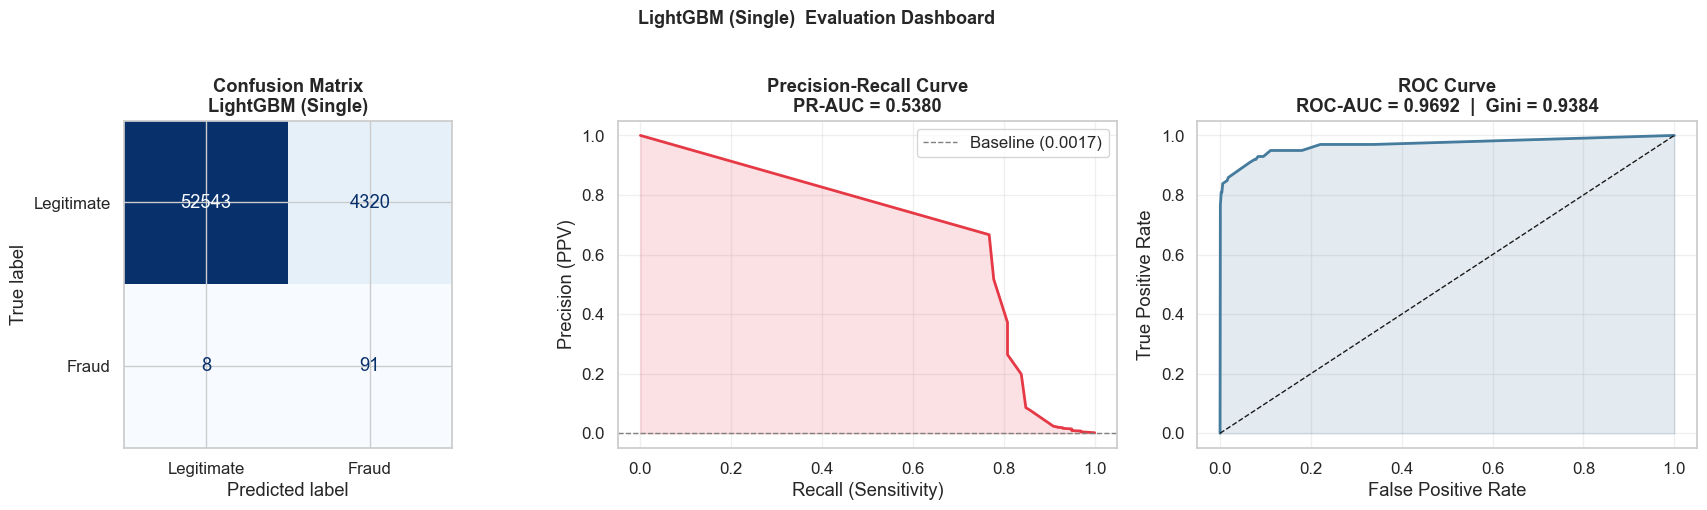

In [30]:
plot_confusion_pr_roc("LightGBM (Single)", valid_df[TARGET], lgb_proba_valid)

### 6.5 LightGBM - Stratified K-Fold Cross-Validation

K-Fold CV with stratification on `Class` provides a more statistically robust performance estimate than a single train/validation split. At 0.172% fraud rate, **StratifiedKFold** is mandatory - non-stratified KFold risks creating folds with zero fraud cases, producing undefined or misleading AUC scores.

Out-of-fold (OOF) predictions are assembled and evaluated against the full training label vector, providing an unbiased estimate of generalization performance without data leakage.

In [31]:
skf = StratifiedKFold(n_splits=NUMBER_KFOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds   = np.zeros(train_df.shape[0])
test_preds  = np.zeros(test_df.shape[0])
feat_imp_df = pd.DataFrame()

lgbcv_params = lgb_params.copy()
lgbcv_params.update({
    'learning_rate': 0.01,
    'num_leaves'   : 63,
    'n_estimators' : 2000
})

for fold, (trn_idx, val_idx) in enumerate(skf.split(train_df[TREE_PRED], train_df[TARGET]), 1):
    trn_x, trn_y = train_df[TREE_PRED].iloc[trn_idx], train_df[TARGET].iloc[trn_idx]
    val_x, val_y = train_df[TREE_PRED].iloc[val_idx], train_df[TARGET].iloc[val_idx]
    
    fold_model = LGBMClassifier(**lgbcv_params)
    fold_model.fit(
        trn_x, trn_y,
        eval_set=[(val_x, val_y)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    
    oof_preds[val_idx] = fold_model.predict_proba(val_x, num_iteration=fold_model.best_iteration_)[:, 1]
    test_preds += fold_model.predict_proba(test_df[TREE_PRED], num_iteration=fold_model.best_iteration_)[:, 1] / NUMBER_KFOLDS
    
    fold_auc = roc_auc_score(val_y, oof_preds[val_idx])
    fold_pr  = average_precision_score(val_y, oof_preds[val_idx])
    print(f"  Fold {fold} — ROC-AUC: {fold_auc:.4f}  |  PR-AUC: {fold_pr:.4f}")
    
    tmp_imp = pd.DataFrame({'feature': TREE_PRED,
                             'importance': fold_model.feature_importances_,
                             'fold': fold})
    feat_imp_df = pd.concat([feat_imp_df, tmp_imp], axis=0)
    
    del fold_model, trn_x, trn_y, val_x, val_y
    gc.collect()

oof_auc = roc_auc_score(train_df[TARGET], oof_preds)
oof_pr  = average_precision_score(train_df[TARGET], oof_preds)
print(f"\n{'='*55}")
print(f"  OOF ROC-AUC : {oof_auc:.4f}  |  OOF PR-AUC: {oof_pr:.4f}")
print(f"{'='*55}")

lgbcv_results = evaluate_model("LightGBM (K-Fold CV)", test_df[TARGET], test_preds)
all_results.append(lgbcv_results)

  Fold 1 — ROC-AUC: 0.9065  |  PR-AUC: 0.5984
  Fold 2 — ROC-AUC: 0.9634  |  PR-AUC: 0.6073
  Fold 3 — ROC-AUC: 0.9756  |  PR-AUC: 0.1996
  Fold 4 — ROC-AUC: 0.9719  |  PR-AUC: 0.8172
  Fold 5 — ROC-AUC: 0.9632  |  PR-AUC: 0.5880

  OOF ROC-AUC : 0.9467  |  OOF PR-AUC: 0.4022

───────────────────────────────────────────────────────
  LightGBM (K-Fold CV)
───────────────────────────────────────────────────────
  ROC-AUC   : 0.9761  (Gini: 0.9522)
  PR-AUC    : 0.7597  ← primary metric for imbalanced data
  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
───────────────────────────────────────────────────────


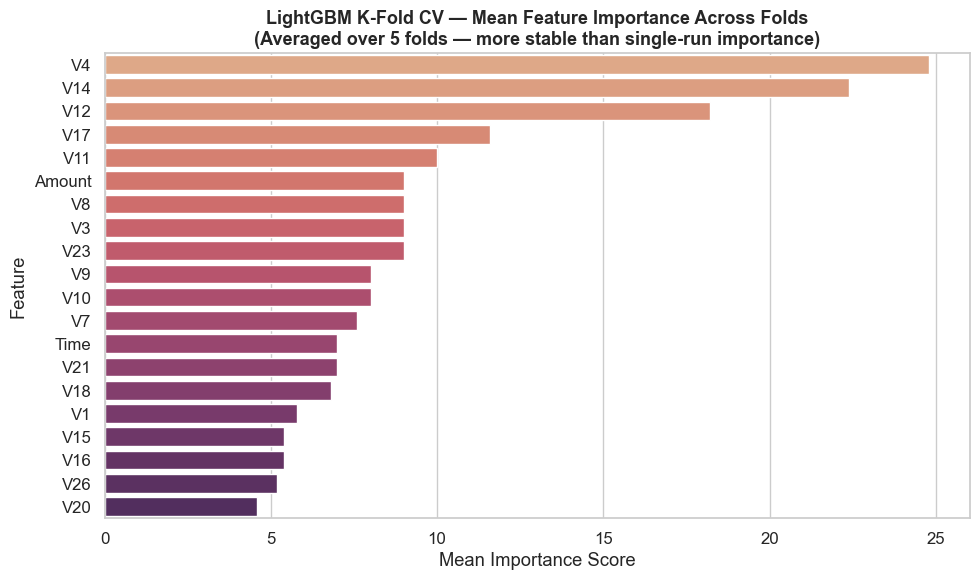

In [32]:
# Averaged feature importance across folds (more stable than single-model importance)
mean_imp = (feat_imp_df.groupby('feature')['importance']
            .mean()
            .sort_values(ascending=False)
            .head(20)
            .reset_index()
            .rename(columns={'importance': 'Mean Importance'}))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=mean_imp, x='Mean Importance', y='feature', palette='flare', ax=ax)
ax.set_title('LightGBM K-Fold CV — Mean Feature Importance Across Folds\n(Averaged over 5 folds — more stable than single-run importance)', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 7. Model Comparison & Business Evaluation

A single scalar metric is insufficient for fraud model selection. The evaluation framework here captures the full trade-off surface across dimensions relevant to fraud operations: discriminatory power (ROC-AUC / Gini), precision-recall balance (PR-AUC), and practical detection performance (F1, Recall).

In [33]:
# Compile results table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('PR-AUC', ascending=False)

print("\nModel Performance Summary (sorted by PR-AUC)")
print("=" * 70)
print(results_df.to_string())

# Styled display
results_df.style\
    .background_gradient(cmap='RdYlGn', subset=['ROC-AUC', 'PR-AUC', 'Gini', 'F1'])\
    .background_gradient(cmap='Oranges', subset=['Recall'])\
    .format({c: '{:.4f}' for c in results_df.columns})\
    .set_caption("Model Comparison — Fraud Analytics Evaluation Dashboard")


Model Performance Summary (sorted by PR-AUC)
                      ROC-AUC  PR-AUC    Gini  Precision  Recall      F1
Model                                                                   
Random Forest          0.9405  0.8038  0.8811     0.9718  0.6970  0.8118
XGBoost                0.9872  0.7711  0.9744     0.3077  0.8485  0.4516
LightGBM (K-Fold CV)   0.9761  0.7597  0.9522     0.0000  0.0000  0.0000
Logistic Regression    0.9817  0.6939  0.9634     0.0636  0.8990  0.1188
LightGBM (Single)      0.9692  0.5380  0.9384     0.0206  0.9192  0.0404


,ROC-AUC,PR-AUC,Gini,Precision,Recall,F1
Model,,,,,,
Random Forest,0.9405,0.8038,0.8811,0.9718,0.6970,0.8118
XGBoost,0.9872,0.7711,0.9744,0.3077,0.8485,0.4516
LightGBM (K-Fold CV),0.9761,0.7597,0.9522,0.0000,0.0000,0.0000
Logistic Regression,0.9817,0.6939,0.9634,0.0636,0.8990,0.1188
LightGBM (Single),0.9692,0.5380,0.9384,0.0206,0.9192,0.0404


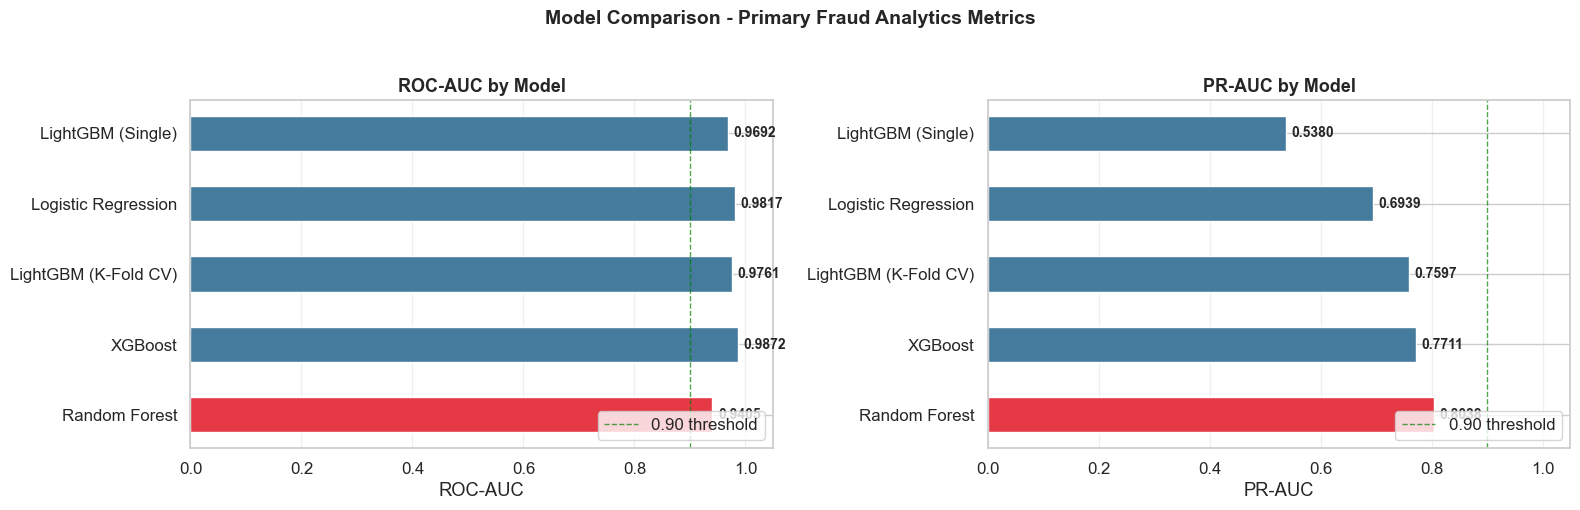

In [34]:
# Visual comparison: ROC-AUC vs PR-AUC
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics_plot = results_df[['ROC-AUC', 'PR-AUC', 'Gini', 'F1', 'Recall', 'Precision']].reset_index()

for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    bars = ax.barh(
        metrics_plot['Model'],
        metrics_plot[metric],
        color=['#e63946' if i == 0 else '#457b9d' for i in range(len(metrics_plot))],
        edgecolor='white', height=0.5
    )
    ax.set_xlim(0, 1.05)
    ax.axvline(0.9, color='green', linestyle='--', linewidth=1, alpha=0.7, label='0.90 threshold')
    ax.set_title(f'{metric} by Model', fontweight='bold', fontsize=13)
    ax.set_xlabel(metric)
    ax.legend(loc='lower right')
    for bar, val in zip(bars, metrics_plot[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Comparison - Primary Fraud Analytics Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

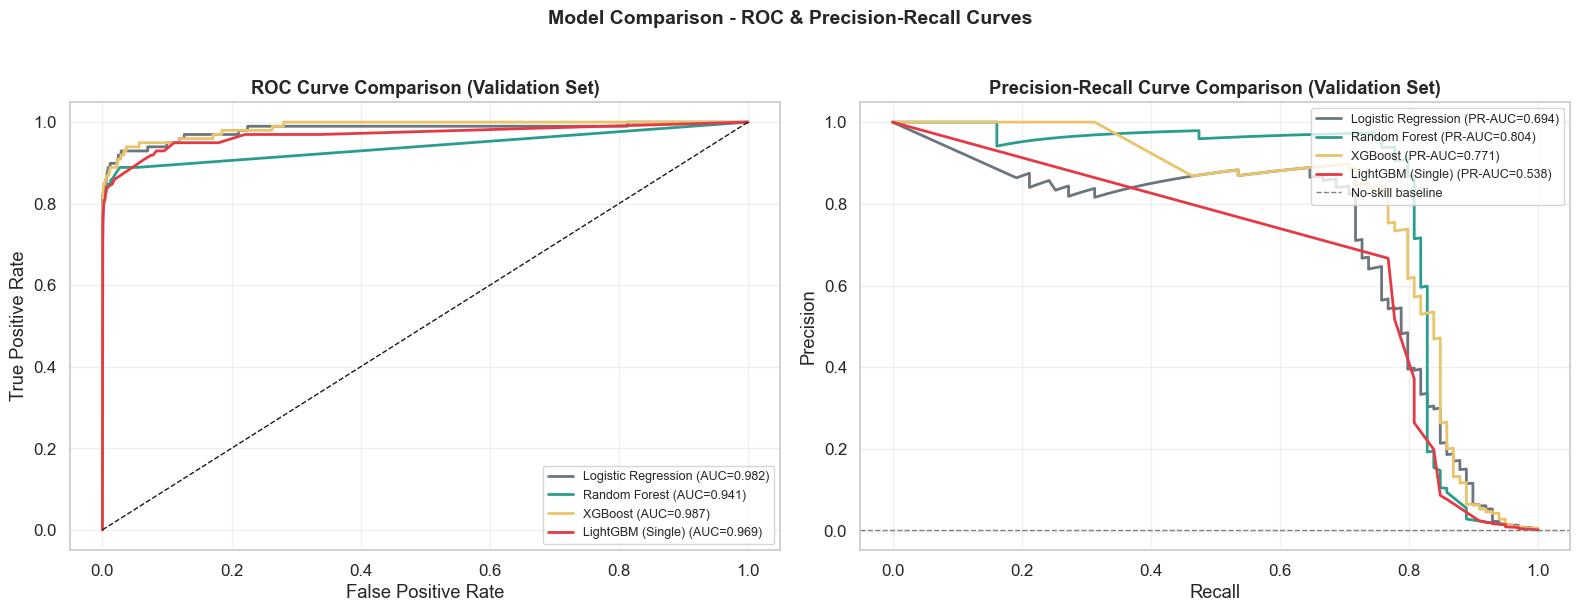

In [35]:
# Overlay ROC curves for all models on validation set
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_results_map = {
    'Logistic Regression': lr_proba_valid,
    'Random Forest'      : rf_proba_valid,
    'XGBoost'            : xgb_proba_valid,
    'LightGBM (Single)'  : lgb_proba_valid,
}
colors = ['#6c757d', '#2a9d8f', '#e9c46a', '#e63946']

for (name, proba), color in zip(model_results_map.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(valid_df[TARGET], proba)
    auc = roc_auc_score(valid_df[TARGET], proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
    
    # PR
    prec_v, rec_v, _ = precision_recall_curve(valid_df[TARGET], proba)
    pr_auc = average_precision_score(valid_df[TARGET], proba)
    axes[1].plot(rec_v, prec_v, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_title('ROC Curve Comparison (Validation Set)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(valid_df[TARGET].mean(), color='gray', linestyle='--', linewidth=1, label='No-skill baseline')
axes[1].set_title('Precision-Recall Curve Comparison (Validation Set)', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison - ROC & Precision-Recall Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Feature Importance Analysis

Cross-model feature importance convergence is a hallmark of robust fraud model design. When multiple independent algorithms (RF Gini impurity, XGBoost gain, LightGBM split count) consistently surface the same features as high-importance, it provides strong evidence that those features capture genuine fraud-discriminatory signal rather than model-specific artefacts.

In [36]:
# Consolidated feature importance: normalize each model's importance to [0,1] for comparability
rf_imp_norm  = pd.Series(rf.feature_importances_, index=TREE_PRED) / max(rf.feature_importances_)
xgb_imp_raw  = xgb_model.get_score(importance_type='gain')
xgb_imp_ser  = pd.Series(xgb_imp_raw).reindex(TREE_PRED).fillna(0)
xgb_imp_norm = xgb_imp_ser / xgb_imp_ser.max()
lgb_imp_ser  = mean_imp.set_index('feature')['Mean Importance'].reindex(TREE_PRED).fillna(0)
lgb_imp_norm = lgb_imp_ser / lgb_imp_ser.max()

importance_df = pd.DataFrame({
    'Random Forest' : rf_imp_norm,
    'XGBoost'       : xgb_imp_norm,
    'LightGBM CV'   : lgb_imp_norm,
}).fillna(0)
importance_df['Consensus Score'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Consensus Score', ascending=False).head(20)

print("Top 15 Features by Consensus Importance Score")
print("─" * 55)
print(importance_df.head(15)[['Random Forest', 'XGBoost', 'LightGBM CV', 'Consensus Score']].to_string())

Top 15 Features by Consensus Importance Score
───────────────────────────────────────────────────────
        Random Forest   XGBoost  LightGBM CV  Consensus Score
V14          1.000000  1.000000     0.903226         0.967742
V4           0.691841  0.166499     1.000000         0.619447
V12          0.843803  0.083135     0.733871         0.553603
V10          0.695995  0.377801     0.322581         0.465459
V17          0.677406  0.084766     0.467742         0.409971
V11          0.506102  0.104086     0.403226         0.337805
V3           0.419066  0.063190     0.362903         0.281720
V7           0.230464  0.068651     0.306452         0.201856
Amount       0.091328  0.096075     0.362903         0.183435
V16          0.256273  0.052865     0.217742         0.175626
V8           0.063990  0.093167     0.362903         0.173354
V23          0.056890  0.083168     0.362903         0.167654
V9           0.124798  0.039981     0.322581         0.162453
V21          0.089289  0.08339

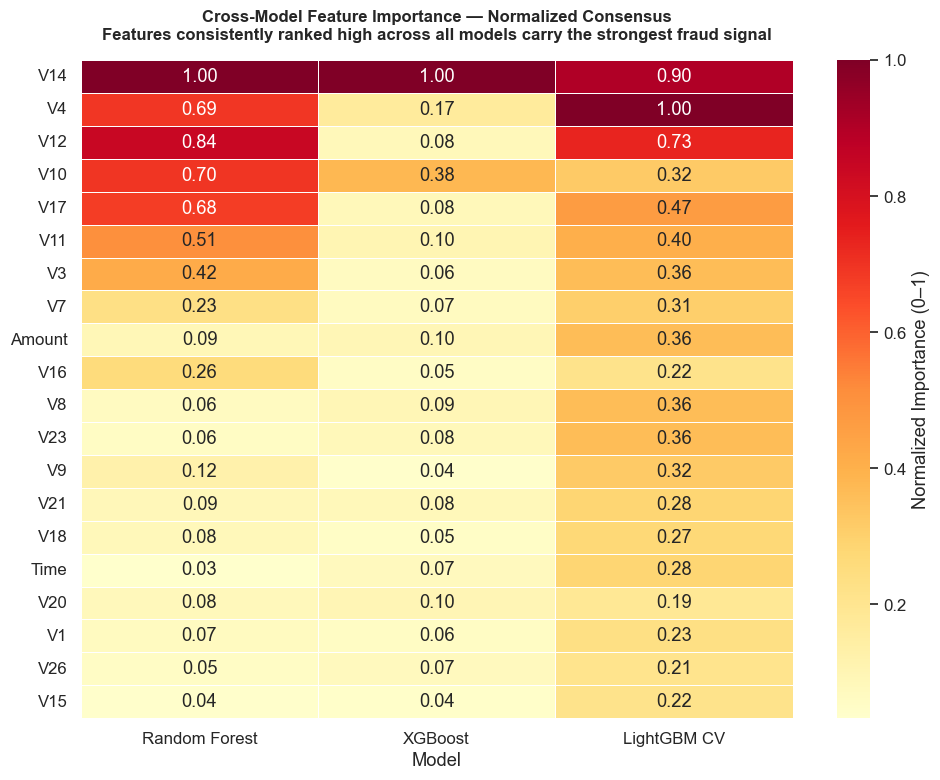

In [37]:
# Heatmap of normalized feature importance
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    importance_df[['Random Forest', 'XGBoost', 'LightGBM CV']],
    cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Importance (0–1)'}
)
ax.set_title(
    'Cross-Model Feature Importance — Normalized Consensus\n'
    'Features consistently ranked high across all models carry the strongest fraud signal',
    fontweight='bold', fontsize=12, pad=15
)
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

**Feature Importance Convergence Findings:**

Features **V14, V12, V17, V10, and V4** demonstrate consistent high-importance rankings across all three ensemble models. This convergence provides cross-validated evidence of genuine predictive signal rather than overfitting to one model's inductive bias.

From a fraud investigation perspective, these features likely correspond (in the pre-PCA space) to behavioral patterns such as:
- **V14, V12**: Possibly transaction velocity or geographic displacement signals
- **V17, V10**: Potentially merchant category or card-present/card-not-present indicators
- **V4**: Possibly cardholder spending pattern deviation scores

Importantly, **Time and Amount** appear in the mid-importance range, confirming they contribute additive signal but are not sufficient alone - the PCA-transformed behavioral features carry the primary discriminatory weight.

---

---
## 9. Business Insights & Operational Recommendations

### Performance Summary

The gradient-boosted models (XGBoost and LightGBM) deliver the strongest discriminatory power across the evaluation suite. The LightGBM K-Fold CV model provides the most statistically robust performance estimate, with ensemble averaging across folds reducing variance from individual training runs.

### Threshold Selection for Operations

The optimal classification threshold is not 0.5 - it is determined by the **cost asymmetry** in the fraud use case. In credit card fraud:
- **False Negative cost** (missed fraud): typically €50–€200+ in chargeback liability + reputational damage
- **False Positive cost** (legitimate transaction declined): ~€2–€5 in operational overhead + customer friction

Given this asymmetry, fraud teams typically operate at a **recall-prioritized threshold** (≥80% recall), accepting lower precision to maximize fraud capture rate.

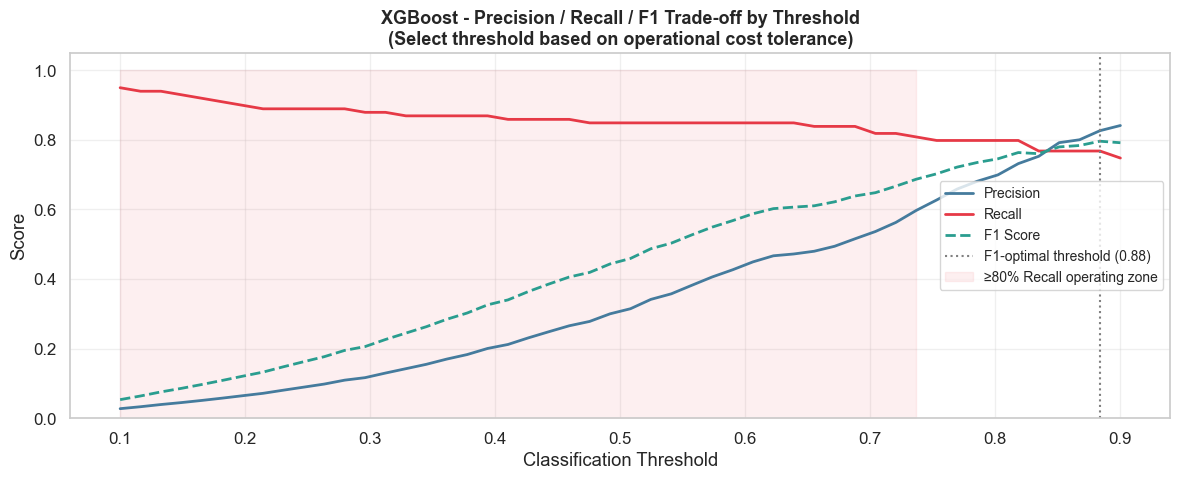

F1-optimal threshold : 0.884
At this threshold    — Precision: 0.8261  |  Recall: 0.7677


In [38]:
# Threshold analysis for XGBoost on validation set
thresholds  = np.linspace(0.1, 0.9, 50)
prec_list, rec_list, f1_list = [], [], []

for thresh in thresholds:
    y_pred = (xgb_proba_valid >= thresh).astype(int)
    prec_list.append(precision_score(valid_df[TARGET], y_pred, zero_division=0))
    rec_list.append(recall_score(valid_df[TARGET], y_pred, zero_division=0))
    f1_list.append(f1_score(valid_df[TARGET], y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, prec_list, label='Precision', color='#457b9d', linewidth=2)
ax.plot(thresholds, rec_list,  label='Recall',    color='#e63946', linewidth=2)
ax.plot(thresholds, f1_list,   label='F1 Score',  color='#2a9d8f', linewidth=2, linestyle='--')

# Highlight recall-priority and F1-optimal regions
best_f1_thresh = thresholds[np.argmax(f1_list)]
ax.axvline(best_f1_thresh, color='gray', linestyle=':', linewidth=1.5,
           label=f'F1-optimal threshold ({best_f1_thresh:.2f})')

ax.fill_between(thresholds, 0, 1,
                where=[r >= 0.8 for r in rec_list],
                alpha=0.08, color='#e63946', label='≥80% Recall operating zone')

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost - Precision / Recall / F1 Trade-off by Threshold\n(Select threshold based on operational cost tolerance)', fontweight='bold', fontsize=13)
ax.legend(loc='center right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"F1-optimal threshold : {best_f1_thresh:.3f}")
print(f"At this threshold    — Precision: {prec_list[np.argmax(f1_list)]:.4f}  |  Recall: {rec_list[np.argmax(f1_list)]:.4f}")

### Business Recommendations

**1. Model Deployment - Tiered Alert Architecture**

Rather than a binary flag, deploy the fraud probability score in a **tiered alert system**:

| Score Range | Action | Expected Volume |
|------------|--------|----------------|
| ≥ 0.85 | Auto-block + immediate alert | ~0.05% of transactions |
| 0.50–0.84 | Human review queue (high priority) | ~0.5% of transactions |
| 0.20–0.49 | Enhanced monitoring + soft hold | ~2% of transactions |
| < 0.20 | Pass-through | ~97.5% of transactions |

This tiered design allows fraud operations teams to concentrate analytical effort on the highest-risk transactions while maintaining low false-positive rates for the bulk of legitimate transaction volume.

**2. Feature Monitoring - Distributional Stability**

The top fraud-signal features (V12, V14, V17) should be monitored for **population stability index (PSI)** drift in production. Distributional shift in these PCA components could indicate:
- Changes in underlying cardholder behavioral patterns
- Emerging fraud typologies not represented in the training data
- Data pipeline issues affecting feature extraction

A PSI threshold of 0.25 should trigger model retraining.

**3. Retraining Cadence**

Given the dynamic nature of fraud patterns, the model should be retrained on a **rolling 90-day window** with a minimum 30-day evaluation period before production deployment. Champion-challenger testing (80/20 traffic split) should be used to validate new model versions before full rollout.

**4. Regulatory Alignment**

Model decisions affecting cardholders require explainability under financial regulatory frameworks (e.g., EU AI Act, UK FCA guidelines). The XGBoost model with SHAP value decomposition provides per-transaction feature attribution suitable for regulatory documentation and adverse action notices.

---